In [2]:
import pandas as pd

In [3]:
df = pd.read_excel(r"D:\Projects\Customer Churn Prediction & Retention Analysis\Telco_customer_churn.xlsx")
df.head(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.shape

(7043, 33)

In [5]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [6]:
df.drop(columns=[
    'CustomerID',
    'Count',
    'Country',
    'State',
    'Latitude',
    'Longitude',
    'Lat Long',
    'Zip Code',
    'Churn Score',
    'Churn Reason',
    'Churn Label',
    'CLTV'
], inplace=True)

In [7]:
df.shape

(7043, 21)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

City                 0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Value          0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [11]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'],errors = 'coerce')
print(df['Total Charges'].dtype)
print(df['Total Charges'].isnull().sum())

float64
11


In [12]:
df.dropna(subset=['Total Charges'], inplace=True)

print(df.isnull().sum())
print(df.shape)

City                 0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Value          0
dtype: int64
(7032, 21)


# EDA 

Before starting the EDA, I didn't want to create graphs directly. First, I wanted to understand the business problem. The goal of this project is to find why customers are leaving the company. So I asked myself, "What factors can affect a customer's decision to leave?" Based on that, I selected the most important columns like Contract, Tenure, Monthly Charges, Total Charges, Payment Method, Internet Service, Gender, Partner, Dependents, Senior Citizen, and other services.

Then I converted these thoughts into business questions:

* Which contract type has the highest churn?
* Does tenure affect customer churn?
* Do customers with higher monthly charges churn more?
* Does Total Charges affect churn?
* Which payment method has the highest churn?
* Does Internet Service affect churn?
* Do Senior Citizens churn more?
* Does gender affect churn?
* Does having a partner affect churn?
* Does having dependents affect churn?
* Which services are associated with higher churn?

After making these questions, I used the data to check whether my assumptions were correct or not. This helped me understand the dataset before creating visualizations or building the machine learning model.


In [27]:
# 1.contract vs churn value 
pd.crosstab(df["Contract"], df["Churn Value"], normalize="index") * 100

Churn Value,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [21]:
# 2.tenure month vs churn value 
df.groupby("Churn Value")["Tenure Months"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
1,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [28]:
# 3.Monthly charges vs churn
df.groupby("Churn Value")["Monthly Charges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
1,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


In [29]:
# 4.Total Charges vs churn
df.groupby("Churn Value")["Total Charges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5163.0,2555.344141,2329.456984,18.80,577.825,1683.60,4264.125,8672.45
1,1869.0,1531.796094,1890.822994,18.85,134.500,703.55,2331.300,8684.80


In [30]:
# 5.payment method vs churn
pd.crosstab(df["Payment Method"], df["Churn Value"], normalize="index") * 100

Churn Value,0,1
Payment Method,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


In [31]:
# 6.Internet service vs churn
pd.crosstab(df["Internet Service"], df["Churn Value"], normalize="index") * 100

Churn Value,0,1
Internet Service,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


In [32]:
# 7.Senior Citizens vs churn
pd.crosstab(df["Senior Citizen"], df["Churn Value"], normalize="index") * 100

Churn Value,0,1
Senior Citizen,,
No,76.349745,23.650255
Yes,58.318739,41.681261


In [33]:
# 8.Gender vs churn
pd.crosstab(df["Gender"], df["Churn Value"], normalize="index") * 100

Churn Value,0,1
Gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


In [34]:
# 9.partner vs churn
pd.crosstab(df["Partner"], df["Churn Value"], normalize="index") * 100

Churn Value,0,1
Partner,,
No,67.023908,32.976092
Yes,80.282935,19.717065


In [35]:
# 10.Dependents vs churn
pd.crosstab(df["Dependents"], df["Churn Value"], normalize="index") * 100

Churn Value,0,1
Dependents,,
No,67.424242,32.575758
Yes,93.456790,6.543210


In [36]:
# 11.online security vs churn 
pd.crosstab(df["Online Security"], df["Churn Value"], normalize="index") * 100

Churn Value,0,1
Online Security,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


In [37]:
# 12.tech support vs churn
pd.crosstab(df["Tech Support"], df["Churn Value"], normalize="index") * 100

Churn Value,0,1
Tech Support,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


In [38]:
# 13.online backup vs churn 
pd.crosstab(df["Online Backup"], df["Churn Value"], normalize="index") * 100

Churn Value,0,1
Online Backup,,
No,60.058309,39.941691
No internet service,92.565789,7.434211
Yes,78.432990,21.567010


In [39]:
# 14.device protection vs churn 
pd.crosstab(df["Device Protection"], df["Churn Value"], normalize="index") * 100

Churn Value,0,1
Device Protection,,
No,60.859729,39.140271
No internet service,92.565789,7.434211
Yes,77.460711,22.539289


In [40]:
# 15.streaming tv vs churn
pd.crosstab(df["Streaming TV"], df["Churn Value"], normalize="index") * 100

Churn Value,0,1
Streaming TV,,
No,66.464934,33.535066
No internet service,92.565789,7.434211
Yes,69.885313,30.114687


# 1. Contract Type vs Churn
   
Insight

-Customers with Month-to-Month contracts have the highest churn rate (42.71%).
-Customers with One-Year contracts have a much lower churn rate (11.28%).
-Customers with Two-Year contracts have the lowest churn rate (2.85%).

Business Recommendation

-Encourage Month-to-Month customers to switch to One-Year or Two-Year contracts by offering discounts, loyalty rewards, or special benefits.

# 2. Tenure vs Churn
   
Insight

-Customers who churn stayed with the company for an average of 17.97 months.
-Customers who did not churn stayed for an average of 37.65 months.
-This shows that customers with shorter tenure are more likely to leave the company.

Business Recommendation

-Focus on retaining new customers during their first 1–2 years by providing better customer support, onboarding, and attractive offers.

# 3. Monthly Charges vs Churn

Insight

-Customers who churn pay an average monthly charge of 74.44.
-Customers who stay pay an average monthly charge of 61.31.
-Higher monthly charges are associated with a higher chance of churn.

Business Recommendation

-Review expensive plans and provide better value through discounts, bundled services, or flexible pricing.

# 4. Total Charges vs Churn

Insight

-Customers who stayed have much higher Total Charges because they remained with the company for a longer period.
-Total Charges alone do not directly affect churn because they also depend on customer tenure.

Business Recommendation

-Analyze Total Charges together with Tenure before making business decisions.

# 5. Payment Method vs Churn

Insight

-Customers using Electronic Check have the highest churn rate (45.29%).
-Customers using automatic payment methods have much lower churn rates.

Business Recommendation

-Encourage customers to switch from Electronic Check to automatic payment methods by providing cashback or rewards.

# 6. Internet Service vs Churn

Insight

-Customers using Fiber Optic internet have the highest churn rate (41.89%).
-DSL customers have a lower churn rate.
-Customers without internet service have the lowest churn rate.

Business Recommendation

-Improve the quality, pricing, and customer support for Fiber Optic users to reduce churn.

# 7. Senior Citizen vs Churn

Insight

-Senior Citizens have a churn rate of 41.68%.
-Non-Senior Citizens have a churn rate of 23.65%.
-Senior Citizens are more likely to leave the company.

Business Recommendation

-Offer special discounts, personalized support, and senior-friendly plans to improve customer retention.

# 8. Gender vs Churn

Insight

-Male and Female customers have almost the same churn rate.
-Gender has very little impact on customer churn.

Business Recommendation

-Gender should not be considered an important factor while planning customer retention strategies.

# 9. Partner vs Churn

Insight

-Customers without a partner have a churn rate of 32.98%.
-Customers with a partner have a churn rate of 19.72%.
-Customers with a partner are more likely to stay with the company.

Business Recommendation

-Introduce family plans or partner discounts to encourage long-term subscriptions.

# 10. Dependents vs Churn

Insight

-Customers without dependents have a churn rate of 32.58%.
-Customers with dependents have a churn rate of 6.54%.
-Customers with dependents are much less likely to churn.

Business Recommendation

-Provide family-oriented plans and benefits to improve customer retention.

# 11. Online Security vs Churn

Insight

-Customers without Online Security have a churn rate of 41.78%.
-Customers with Online Security have a churn rate of 14.64%.
-Online Security is strongly associated with lower churn.

Business Recommendation

-Promote Online Security as an add-on service or include it in premium plans.

# 12. Tech Support vs Churn

Insight

-Customers without Tech Support have a churn rate of 41.65%.
-Customers with Tech Support have a churn rate of 15.20%.
-Customers using Tech Support are much less likely to churn.

Business Recommendation

-Encourage customers to subscribe to Tech Support through free trials or bundled offers.

# 13. Online Backup vs Churn

Insight

-Customers without Online Backup have a churn rate of 39.94%.
-Customers with Online Backup have a churn rate of 21.57%.
-Online Backup is associated with better customer retention.

Business Recommendation

-Promote Online Backup services as part of premium subscription plans.

# 14. Device Protection vs Churn

Insight

-Customers without Device Protection have a churn rate of 39.14%.
-Customers with Device Protection have a churn rate of 22.54%.
-Device Protection helps reduce customer churn.

Business Recommendation

-Bundle Device Protection with internet or phone plans to increase customer retention.

# 15. Streaming TV vs Churn

Insight

-Customers without Streaming TV have a churn rate of 33.54%.
-Customers with Streaming TV have a churn rate of 30.11%.
-Streaming TV has only a small impact on customer churn.

Business Recommendation

Streaming TV alone is not a strong retention factor. It should be combined with other valuable services such as Online Security or Tech Support.


# Overall EDA Conclusion

Key Findings

-Customers with Month-to-Month contracts are the most likely to churn.
-Customers with shorter tenure have a higher churn rate.
-Higher Monthly Charges are associated with higher churn.
-Electronic Check users have the highest churn among payment methods.
-Fiber Optic customers churn more than other internet service users.
-Senior Citizens have a higher churn rate than non-senior citizens.
-Customers without Online Security, Tech Support, Online Backup, and Device Protection are more likely to churn.
-Gender has very little impact on customer churn.


# Final Business Recommendation

The company should focus on customers who have Month-to-Month contracts, short tenure, high monthly charges, Electronic Check payment methods, and who do not use value-added services like Online Security or Tech Support. Providing personalized offers, loyalty programs, and service bundles for these customers can help reduce churn and improve customer retention.

In [41]:
df["City"].nunique()

1129

In [42]:
df["City"].value_counts().head(10)

City
Los Angeles      304
San Diego        150
San Jose         112
Sacramento       108
San Francisco    104
Fresno            64
Long Beach        60
Oakland           52
Stockton          44
Bakersfield       40
Name: count, dtype: int64

In [43]:
df = df.drop("City", axis=1)

In [59]:
# Find all categorical columns
categorical_columns = df.select_dtypes(include="object").columns

# Encode all categorical columns
df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

# Check the result
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Tenure Months                           7032 non-null   int64  
 1   Monthly Charges                         7032 non-null   float64
 2   Total Charges                           7032 non-null   float64
 3   Churn Value                             7032 non-null   int64  
 4   Gender_Male                             7032 non-null   int64  
 5   Contract_One year                       7032 non-null   int64  
 6   Contract_Two year                       7032 non-null   int64  
 7   Senior Citizen_Yes                      7032 non-null   int64  
 8   Partner_Yes                             7032 non-null   int64  
 9   Dependents_Yes                          7032 non-null   int64  
 10  Phone Service_Yes                       7032 non-null   int64  
 

In [60]:
df.columns.tolist()

['Tenure Months',
 'Monthly Charges',
 'Total Charges',
 'Churn Value',
 'Gender_Male',
 'Contract_One year',
 'Contract_Two year',
 'Senior Citizen_Yes',
 'Partner_Yes',
 'Dependents_Yes',
 'Phone Service_Yes',
 'Multiple Lines_No phone service',
 'Multiple Lines_Yes',
 'Internet Service_Fiber optic',
 'Internet Service_No',
 'Online Security_No internet service',
 'Online Security_Yes',
 'Online Backup_No internet service',
 'Online Backup_Yes',
 'Device Protection_No internet service',
 'Device Protection_Yes',
 'Tech Support_No internet service',
 'Tech Support_Yes',
 'Streaming TV_No internet service',
 'Streaming TV_Yes',
 'Streaming Movies_No internet service',
 'Streaming Movies_Yes',
 'Paperless Billing_Yes',
 'Payment Method_Credit card (automatic)',
 'Payment Method_Electronic check',
 'Payment Method_Mailed check']

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Tenure Months                           7032 non-null   int64  
 1   Monthly Charges                         7032 non-null   float64
 2   Total Charges                           7032 non-null   float64
 3   Churn Value                             7032 non-null   int64  
 4   Gender_Male                             7032 non-null   int64  
 5   Contract_One year                       7032 non-null   int64  
 6   Contract_Two year                       7032 non-null   int64  
 7   Senior Citizen_Yes                      7032 non-null   int64  
 8   Partner_Yes                             7032 non-null   int64  
 9   Dependents_Yes                          7032 non-null   int64  
 10  Phone Service_Yes                       7032 non-null   int64  
 

In [61]:
# Separate Features and Target

X = df.drop("Churn Value", axis=1)
y = df["Churn Value"]

In [62]:
print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (7032, 30)
Target (y): (7032,)


In [63]:
X.head()

,Tenure Months,Monthly Charges,Total Charges,Gender_Male,Contract_One year,Contract_Two year,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,...,Tech Support_No internet service,Tech Support_Yes,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,1
1,2,70.70,151.65,0,0,0,0,0,1,1,...,0,0,0,0,0,0,1,0,1,0
2,8,99.65,820.50,0,0,0,0,0,1,1,...,0,0,0,1,0,1,1,0,1,0
3,28,104.80,3046.05,0,0,0,0,1,1,1,...,0,1,0,1,0,1,1,0,1,0
4,49,103.70,5036.30,1,0,0,0,0,1,1,...,0,0,0,1,0,1,1,0,0,0


In [65]:

y.head()

0    1
1    1
2    1
3    1
4    1
Name: Churn Value, dtype: int64

In [67]:
# Train and test 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [68]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5625, 30)
X_test : (1407, 30)
y_train: (5625,)
y_test : (1407,)


In [69]:
print(y.value_counts(normalize=True))

print("---------------------")

print(y_train.value_counts(normalize=True))

print("---------------------")

print(y_test.value_counts(normalize=True))

Churn Value
0    0.734215
1    0.265785
Name: proportion, dtype: float64
---------------------
Churn Value
0    0.734222
1    0.265778
Name: proportion, dtype: float64
---------------------
Churn Value
0    0.734186
1    0.265814
Name: proportion, dtype: float64


In [70]:
# Feature Scaling 

from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Columns to scale
numerical_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

# Fit only on training data
X_train[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

# Transform test data
X_test[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

In [71]:
# Training first model 

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred_prob = model.predict_proba(X_test)[:, 1]

# Compare Actual vs Predicted

prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

prediction_df.head(10)

,Actual,Predicted
2595,0,0
2337,0,1
5032,0,0
975,1,0
5212,0,0
110,1,0
6208,0,0
4366,0,0
354,1,1
6053,0,0


In [73]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8045486851457001


In [76]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8045486851457001

Confusion Matrix:
[[907 126]
 [149 225]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.64      0.60      0.62       374

    accuracy                           0.80      1407
   macro avg       0.75      0.74      0.74      1407
weighted avg       0.80      0.80      0.80      1407



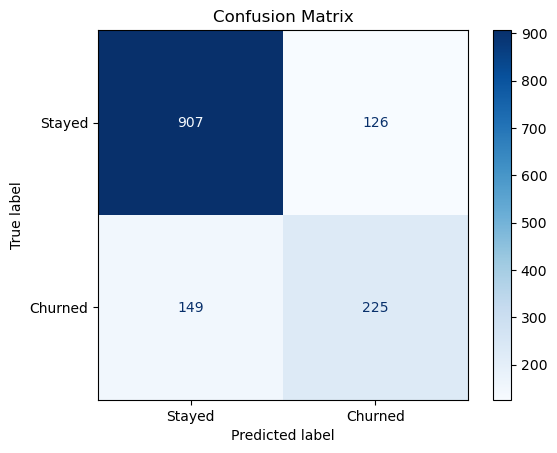

In [77]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Stayed", "Churned"],
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.show()

In [79]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.8432049841849967


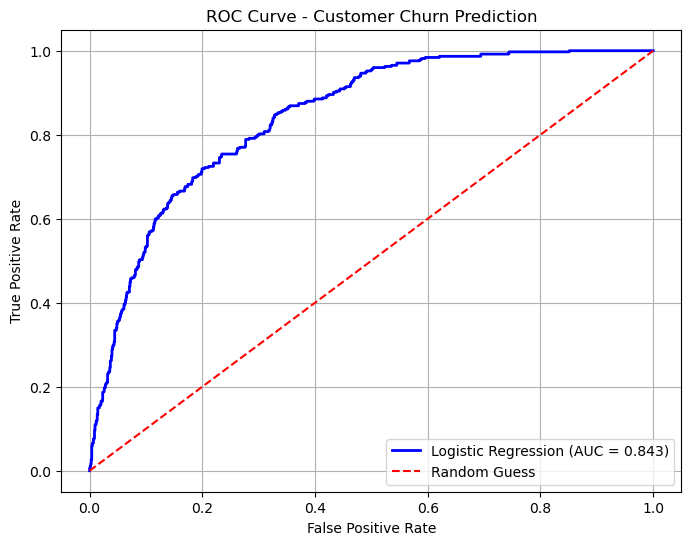

In [80]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr,
         color='blue',
         linewidth=2,
         label=f'Logistic Regression (AUC = {auc_score:.3f})')

# Random Guess Line
plt.plot([0,1],[0,1],
         color='red',
         linestyle='--',
         label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")
plt.legend()
plt.grid(True)

plt.show()

The Logistic Regression model achieved an accuracy of 80.45% and a ROC-AUC score of 0.843, indicating good discrimination between customers who churn and those who stay. The model correctly identified 225 out of 374 customers who churned, achieving a recall of 60%. While the model provides a strong baseline for churn prediction, future improvements using ensemble methods such as Random Forest may further improve recall and overall predictive performance.

In [81]:
# Feature Importance

# Create DataFrame of feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

# Sort by coefficient
feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient
12,Internet Service_Fiber optic,0.948032
2,Total Charges,0.639643
28,Payment Method_Electronic check,0.377710
11,Multiple Lines_Yes,0.353836
23,Streaming TV_Yes,0.344229
25,Streaming Movies_Yes,0.300104
26,Paperless Billing_Yes,0.277143
7,Partner_Yes,0.230128
29,Payment Method_Mailed check,0.074085
6,Senior Citizen_Yes,0.066959


In [86]:
# Random Forest ml model

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

y_pred_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [83]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_pred_prob_rf))

Accuracy: 0.7867803837953091

Confusion Matrix:
[[915 118]
 [182 192]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


ROC-AUC Score:
0.8275219882901679


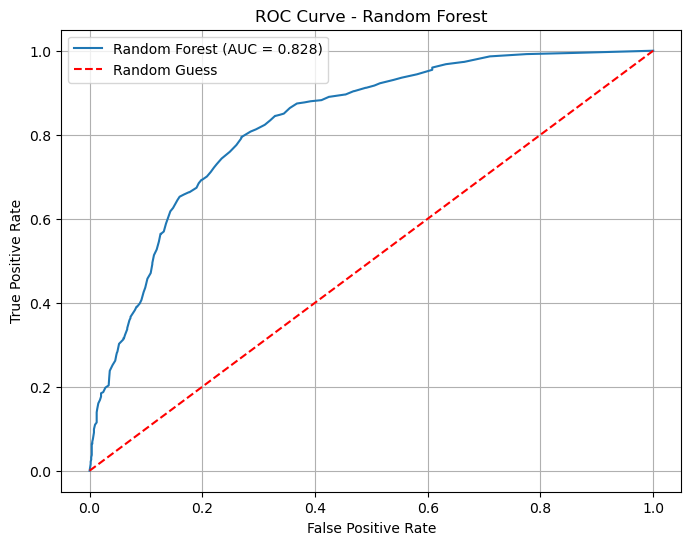

In [84]:
# ROC Curve

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_prob_rf):.3f})'
)

plt.plot([0,1],[0,1],'r--',label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)

plt.show()

In [85]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_pred_prob_rf))

Accuracy: 0.7867803837953091

Confusion Matrix:
[[915 118]
 [182 192]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


ROC-AUC Score:
0.8275219882901679


# Analysis

The objective of this project is to identify customers who are likely to churn so that the company can take preventive actions.

Although both models performed reasonably well, Logistic Regression consistently outperformed Random Forest across all evaluation metrics.

The Logistic Regression model achieved:

Higher Accuracy
Higher Precision
Higher Recall
Higher F1-Score
Higher ROC-AUC Score

Most importantly, it correctly identified 225 churning customers, whereas Random Forest identified only 192.

This means Logistic Regression detected 33 additional customers who were likely to leave.

Why Logistic Regression Was Selected

Logistic Regression was selected as the final model because it provided the best overall performance on the customer churn dataset.

The reasons include:

# 1. Higher Accuracy

Logistic Regression correctly predicted 80.45% of customers compared to 78.68% for Random Forest.

# 2. Better Recall

Recall is one of the most important metrics in churn prediction because it measures how many customers who actually churned were correctly identified.

Logistic Regression Recall = 60%
Random Forest Recall = 51%

A higher recall means the company can identify more customers at risk of leaving and take retention actions.

# 3. Better ROC-AUC Score

Logistic Regression achieved a ROC-AUC score of 0.843, while Random Forest achieved 0.828.

This indicates that Logistic Regression has a better ability to distinguish between customers who will churn and customers who will stay.

# 4. Better Balance

The Logistic Regression model achieved a better balance between Precision and Recall, resulting in a higher F1-Score.

This makes it a more reliable model for customer churn prediction.

# 5. Business Perspective

From a business point of view, missing a customer who is about to churn can result in revenue loss.

The Logistic Regression model missed 149 churning customers, while Random Forest missed 182.

Therefore, Logistic Regression provides the company with more opportunities to retain customers before they leave.

Final Conclusion

Based on the evaluation metrics and business objective, Logistic Regression was selected as the final model for this project.

It achieved:

Accuracy: 80.45%
Precision: 64%
Recall: 60%
F1-Score: 62%
ROC-AUC: 0.843

Compared to Random Forest, Logistic Regression demonstrated better predictive performance and identified more customers at risk of churn.

Therefore, it is the most suitable model for this customer churn prediction project.

In [92]:
import joblib

joblib.dump(model, "logistic_regression_model.pkl")

['logistic_regression_model.pkl']

In [93]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [94]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']